<a href="https://colab.research.google.com/github/ParigiAnyaReddy0420/flight-advisor-using-ml/blob/main/flight_advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Setup works!")

Setup works!


In [ ]:
import pandas as pd
df = pd.read_csv("/content/Clean_Dataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(300153, 12)
['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [9]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop(columns =["Unnamed: 0"])

In [13]:
df = df.drop_duplicates()

In [14]:
df["stops"].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [15]:
economy = df[df["class"] == "Economy"]
business = df[df["class"]== "Business"]
print(economy.shape, business.shape)

(206666, 11) (93487, 11)


In [16]:
df.sort_values("price",ascending = False).head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
261377,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.50,3,123071
216096,Vistara,UK-811,Delhi,Early_Morning,two_or_more,Evening,Kolkata,Business,10.92,5,117307
215859,Vistara,UK-809,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,116562
277345,Vistara,UK-870,Hyderabad,Night,one,Afternoon,Mumbai,Business,16.42,3,115211
270999,Vistara,UK-772,Kolkata,Morning,one,Evening,Hyderabad,Business,9.50,17,114705


In [17]:
economy.sort_values("price",ascending = True).head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
206099,Indigo,6E-804,Chennai,Evening,one,Night,Hyderabad,Economy,6.75,43,1105
206093,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,43,1105
206094,Indigo,6E-7185,Chennai,Morning,one,Afternoon,Hyderabad,Economy,4.17,43,1105
206095,Indigo,6E-7149,Chennai,Evening,one,Night,Hyderabad,Economy,4.17,43,1105
206440,Indigo,6E-581,Chennai,Morning,one,Evening,Hyderabad,Economy,7.08,47,1105


In [18]:
df.groupby("airline")["price"].mean()

,price
airline,
AirAsia,4091.072742
Air_India,23507.019112
GO_FIRST,5652.007595
Indigo,5324.216303
SpiceJet,6179.278881
Vistara,30396.536302


In [19]:
economy.groupby("airline")["price"].mean().sort_values(ascending = False)

,price
airline,
Vistara,7806.943645
Air_India,7313.682169
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


In [20]:
df.groupby("airline")["price"].agg(["mean", "median", "count"])

,mean,median,count
airline,,,
AirAsia,4091.072742,3276.0,16098
Air_India,23507.019112,11520.0,80892
GO_FIRST,5652.007595,5336.0,23173
Indigo,5324.216303,4453.0,43120
SpiceJet,6179.278881,5654.0,9011
Vistara,30396.536302,15543.0,127859


In [24]:
economy.groupby("days_left")["price"].mean().head(20)

,price
days_left,
1,14613.179410
2,13980.828244
3,13174.050992
4,10901.386284
5,10605.918315
6,10319.679864
7,10471.873164
8,10479.491889
9,11352.916150


In [25]:
df["airline"].value_counts()
df["source_city"].value_counts()

,count
source_city,
Delhi,61343
Mumbai,60896
Bangalore,52061
Kolkata,46347
Hyderabad,40806
Chennai,38700


In [26]:
df["airline"].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


In [27]:
df["is_last_minute"] = df["days_left"] <= 7
df.groupby(["class", "is_last_minute"])["price"].mean()

class     is_last_minute
Business  False             52005.303223
          True              56745.043610
Economy   False              5982.668527
          True              11633.748389
Name: price, dtype: float64

In [28]:
stops_map = {"zero": 0, "one": 1, "two_or_more": 2}
df["stops_num"] = df["stops"].map(stops_map)
df["stops_num"].isnull().sum()

np.int64(0)

In [29]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
 11  is_last_minute    300153 non-null  bool   
 12  stops_num         300153 non-null  int64  
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 27.8+ MB


np.int64(0)

In [31]:
df = df.drop_duplicates()
print(df.shape)

(300153, 13)


In [32]:
df.to_csv("flights_cleaned.csv", index=False)

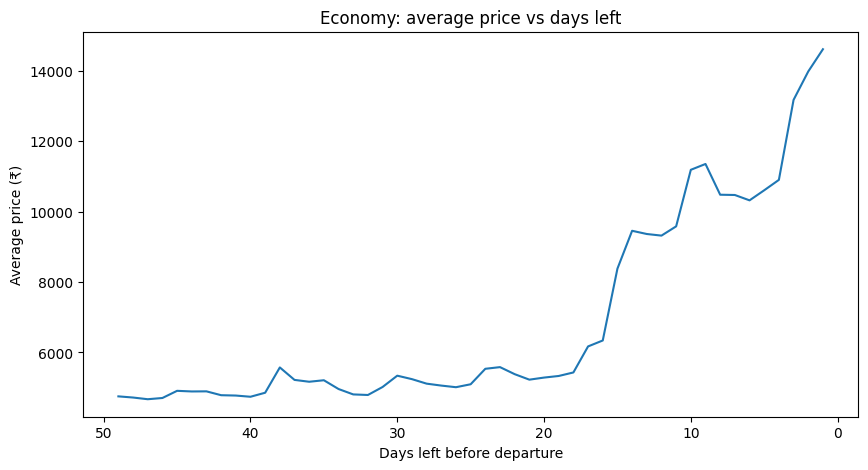

In [37]:
import matplotlib.pyplot as plt

avg_curve = economy.groupby("days_left")["price"].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_curve.index, avg_curve.values)
plt.xlabel("Days left before departure")
plt.ylabel("Average price (₹)")
plt.title("Economy: average price vs days left")
plt.gca().invert_xaxis()   # time moves toward departure, left to right
plt.savefig("price_vs_days_left.png", dpi=150, bbox_inches="tight")
plt.show()

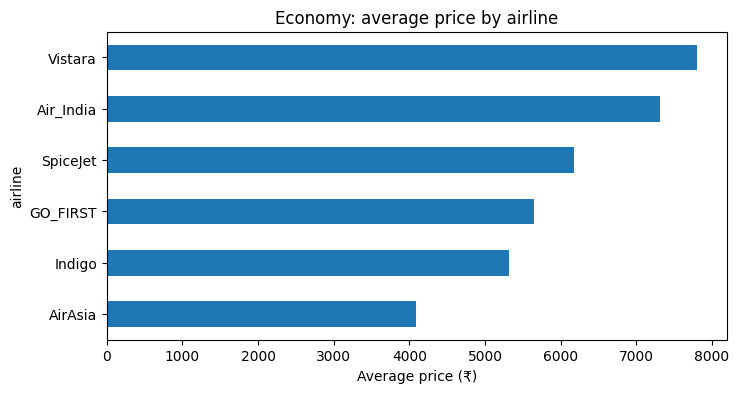

In [34]:
import seaborn as sns

eco_air = economy.groupby("airline")["price"].mean().sort_values()
eco_air.plot(kind="barh", figsize=(8, 4), title="Economy: average price by airline")
plt.xlabel("Average price (₹)")
plt.show()

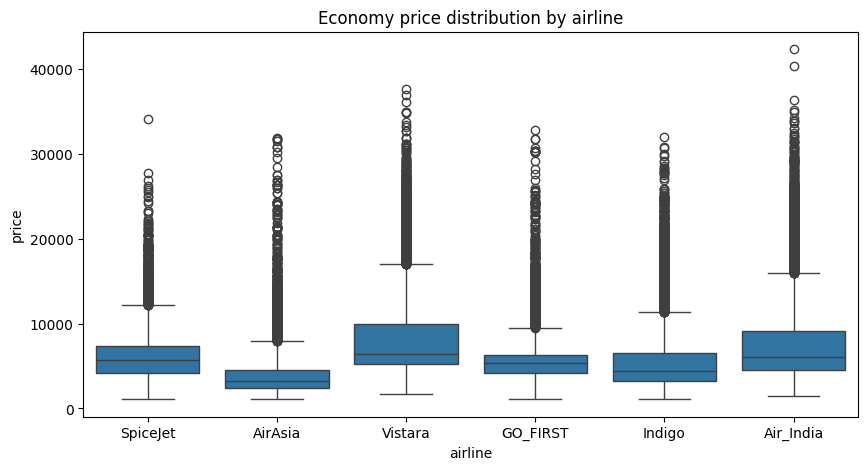

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=economy, x="airline", y="price")
plt.title("Economy price distribution by airline")
plt.show()

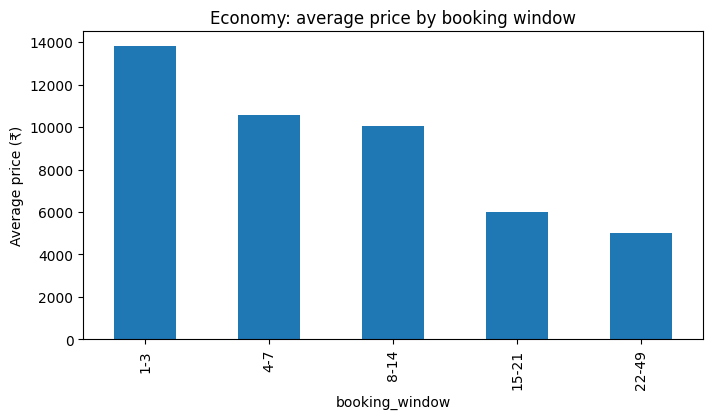

In [36]:
economy = economy.copy()
economy["booking_window"] = pd.cut(economy["days_left"],
                                   bins=[0, 3, 7, 14, 21, 49],
                                   labels=["1-3", "4-7", "8-14", "15-21", "22-49"])
economy.groupby("booking_window", observed=True)["price"].mean().plot(kind="bar", figsize=(8, 4))
plt.ylabel("Average price (₹)")
plt.title("Economy: average price by booking window")
plt.show()

In [38]:
import numpy as np
import pandas as pd

group = ["source_city", "destination_city", "airline",
         "class", "stops", "departure_time"]

daily = (df.groupby(group + ["days_left"])["price"]
           .median()
           .reset_index(name="price_med"))

print(daily.shape)
daily.head()

(77288, 8)


,source_city,destination_city,airline,class,stops,departure_time,days_left,price_med
0,Bangalore,Chennai,AirAsia,Economy,zero,Afternoon,11,3499.0
1,Bangalore,Chennai,AirAsia,Economy,zero,Afternoon,12,3499.0
2,Bangalore,Chennai,AirAsia,Economy,zero,Afternoon,13,3499.0
3,Bangalore,Chennai,AirAsia,Economy,zero,Afternoon,14,3499.0
4,Bangalore,Chennai,AirAsia,Economy,zero,Afternoon,15,3919.0


In [39]:
daily = daily.sort_values(group + ["days_left"])   # days_left goes 1, 2, 3...

daily["cummin"] = daily.groupby(group)["price_med"].cummin()
daily["future_min"] = daily.groupby(group)["cummin"].shift(1)

In [40]:
daily["saving_pct"] = (daily["price_med"] - daily["future_min"]) / daily["price_med"]

threshold = 0.05
daily["label"] = np.where(daily["saving_pct"] > threshold, "wait", "buy_now")

daily["label"].value_counts(normalize=True)

,proportion
label,
buy_now,0.737036
wait,0.262964


In [41]:
first = daily.iloc[0][group]
one = daily[(daily[group] == first).all(axis=1)]
one[["days_left", "price_med", "cummin", "future_min", "saving_pct", "label"]].head(15)

,days_left,price_med,cummin,future_min,saving_pct,label
0,11,3499.0,3499.0,NaN,NaN,buy_now
1,12,3499.0,3499.0,3499.0,0.000000,buy_now
2,13,3499.0,3499.0,3499.0,0.000000,buy_now
3,14,3499.0,3499.0,3499.0,0.000000,buy_now
4,15,3919.0,3499.0,3499.0,0.107170,wait
5,16,1715.0,1715.0,3499.0,-1.040233,buy_now
6,17,1925.0,1715.0,1715.0,0.109091,wait
7,18,1822.0,1715.0,1715.0,0.058727,wait
8,19,1768.5,1715.0,1715.0,0.030252,buy_now
9,20,1822.0,1715.0,1715.0,0.058727,wait


In [42]:
for t in [0.03, 0.05, 0.10]:
    share = (daily["saving_pct"] > t).mean()
    print(f"threshold {t:.0%}: {share:.1%} of group-days labeled 'wait'")

threshold 3%: 29.4% of group-days labeled 'wait'
threshold 5%: 26.3% of group-days labeled 'wait'
threshold 10%: 19.2% of group-days labeled 'wait'


In [43]:
counts = df.groupby(group + ["days_left"]).size()
counts.describe()

,0
count,77288.000000
mean,3.883565
std,3.569891
min,1.000000
25%,1.000000
50%,2.000000
75%,6.000000
max,29.000000


In [44]:
import numpy as np
import pandas as pd

group = ["source_city", "destination_city", "airline",
         "class", "stops", "departure_time"]

rng = np.random.default_rng(42)
flights = df["flight"].unique()
train_f = rng.choice(flights, size=int(0.7 * len(flights)), replace=False)

train = df[df["flight"].isin(train_f)].copy()
test = df[~df["flight"].isin(train_f)].copy()
print(train.shape, test.shape)

(210473, 13) (89680, 13)


In [45]:
def make_daily(data, threshold=0.05):
    d = (data.groupby(group + ["days_left"])
             .agg(price_med=("price", "median"),
                  n=("price", "size"),
                  duration=("duration", "median"))
             .reset_index()
             .sort_values(group + ["days_left"]))

    d["cummin"] = d.groupby(group)["price_med"].cummin()
    d["future_min"] = d.groupby(group)["cummin"].shift(1)
    d["saving_pct"] = (d["price_med"] - d["future_min"]) / d["price_med"]
    d["label"] = (d["saving_pct"] > threshold).astype(int)   # 1 = wait, 0 = buy_now
    return d

train_d = make_daily(train)
test_d = make_daily(test)

print(train_d.shape, test_d.shape)
print(train_d["label"].value_counts(normalize=True))
print(test_d["label"].value_counts(normalize=True))

(63659, 14) (34934, 14)
label
0    0.740681
1    0.259319
Name: proportion, dtype: float64
label
0    0.758602
1    0.241398
Name: proportion, dtype: float64


In [46]:
from sklearn.metrics import classification_report, confusion_matrix

y_test = test_d["label"]

pred_always_buy = np.zeros(len(test_d), dtype=int)
pred_fixed21 = (test_d["days_left"] > 21).astype(int)

for name, p in [("Always buy now", pred_always_buy),
                ("Fixed 21-day rule", pred_fixed21)]:
    print("=====", name)
    print(classification_report(y_test, p, zero_division=0))

===== Always buy now
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     26501
           1       0.00      0.00      0.00      8433

    accuracy                           0.76     34934
   macro avg       0.38      0.50      0.43     34934
weighted avg       0.58      0.76      0.65     34934

===== Fixed 21-day rule
              precision    recall  f1-score   support

           0       0.79      0.42      0.55     26501
           1       0.26      0.65      0.37      8433

    accuracy                           0.47     34934
   macro avg       0.52      0.53      0.46     34934
weighted avg       0.66      0.47      0.51     34934



In [47]:
import lightgbm as lgb

cat_cols = ["source_city", "destination_city", "airline",
            "class", "stops", "departure_time"]
features = cat_cols + ["days_left", "duration"]

for c in cat_cols:
    cats = pd.CategoricalDtype(sorted(df[c].unique()))
    train_d[c] = train_d[c].astype(cats)
    test_d[c] = test_d[c].astype(cats)

model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                           num_leaves=31, class_weight="balanced",
                           random_state=42, verbose=-1)
model.fit(train_d[features], train_d["label"])

LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42, verbose=-1)

In [48]:
test_d["pred"] = model.predict(test_d[features])

print(classification_report(y_test, test_d["pred"]))
print(confusion_matrix(y_test, test_d["pred"]))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76     26501
           1       0.40      0.66      0.50      8433

    accuracy                           0.67     34934
   macro avg       0.63      0.67      0.63     34934
weighted avg       0.75      0.67      0.70     34934

[[17965  8536]
 [ 2833  5600]]


<Axes: title={'center': 'Feature importance'}>

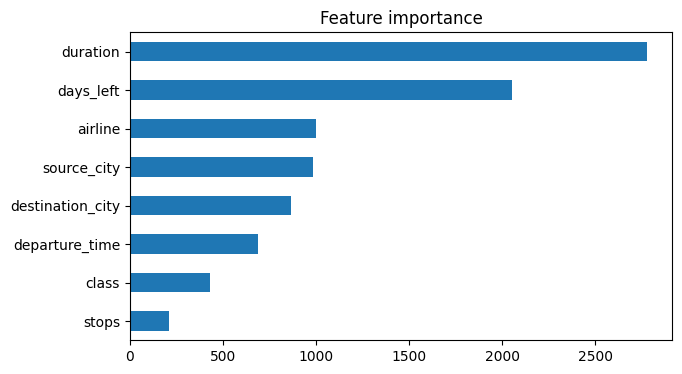

In [49]:
imp = pd.Series(model.feature_importances_, index=features).sort_values()
imp.plot(kind="barh", figsize=(7, 4), title="Feature importance")

In [50]:
import joblib
joblib.dump(model, "advisor_model.pkl")
test_d.to_csv("test_predictions.csv", index=False)

In [51]:
test_d["never_wait"] = 0                                   # always buy now
test_d["fixed_wait"] = (test_d["days_left"] > 21).astype(int)   # wait until 21 days left
test_d["model_wait"] = test_d["pred"].astype(int)          # LightGBM advice

In [52]:
def simulate(d, wait_col):
    rows = []
    for _, g in d.groupby(group, observed=True):
        g = g.sort_values("days_left", ascending=False)   # earliest day first
        p = g["price_med"].to_numpy()
        w = g[wait_col].to_numpy()
        days = g["days_left"].to_numpy()
        n = len(g)
        for i in range(n):
            j = i
            while j < n - 1 and w[j] == 1:     # keep waiting while told to wait
                j += 1
            rows.append((days[i], p[i], p[j], days[j], g["class"].iloc[0]))
    return pd.DataFrame(rows, columns=["start_day", "price_now", "price_paid",
                                       "day_paid", "class"])

In [53]:
def oracle(d):
    """Perfect hindsight: the cheapest price on any day from the start onward."""
    rows = []
    for _, g in d.groupby(group, observed=True):
        g = g.sort_values("days_left", ascending=False)
        p = g["price_med"].to_numpy()
        for i in range(len(g)):
            rows.append((g["days_left"].iloc[i], p[i], p[i:].min(), None, g["class"].iloc[0]))
    return pd.DataFrame(rows, columns=["start_day", "price_now", "price_paid",
                                       "day_paid", "class"])

sims = {
    "Always buy now": simulate(test_d, "never_wait"),
    "Fixed 21-day rule": simulate(test_d, "fixed_wait"),
    "LightGBM advisor": simulate(test_d, "model_wait"),
    "Perfect hindsight (upper bound)": oracle(test_d),
}

rows = []
for name, s in sims.items():
    rows.append({
        "Strategy": name,
        "Avg price paid (₹)": s["price_paid"].mean(),
        "Saving vs buy now (%)": (1 - s["price_paid"].sum() / s["price_now"].sum()) * 100,
        "Regret: paid more (%)": (s["price_paid"] > s["price_now"]).mean() * 100,
    })

results = pd.DataFrame(rows).round(2)
print(results)

                          Strategy  Avg price paid (₹)  Saving vs buy now (%)  \
0                   Always buy now            16719.79                   0.00   
1                Fixed 21-day rule            16811.66                  -0.55   
2                 LightGBM advisor            17411.57                  -4.14   
3  Perfect hindsight (upper bound)            15919.09                   4.79   

   Regret: paid more (%)  
0                   0.00  
1                  15.96  
2                  19.84  
3                   0.00  


In [54]:
for name, s in sims.items():
    s["window"] = pd.cut(s["start_day"], bins=[0, 7, 14, 21, 35, 49],
                         labels=["1-7", "8-14", "15-21", "22-35", "36-49"])

by_win = pd.DataFrame({
    name: s.groupby("window", observed=True)
           .apply(lambda x: (1 - x["price_paid"].sum() / x["price_now"].sum()) * 100)
    for name, s in sims.items()
}).round(1)
print(by_win)

        Always buy now  Fixed 21-day rule  LightGBM advisor  \
window                                                        
1-7                0.0                0.0              -0.6   
8-14               0.0                0.0              -1.1   
15-21              0.0                0.0              -4.3   
22-35              0.0               -0.4              -5.9   
36-49              0.0               -1.6              -6.0   

        Perfect hindsight (upper bound)  
window                                   
1-7                                 4.8  
8-14                                6.0  
15-21                               4.6  
22-35                               4.2  
36-49                               4.7  


/tmp/ipykernel_1808/655011226.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (1 - x["price_paid"].sum() / x["price_now"].sum()) * 100)
/tmp/ipykernel_1808/655011226.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (1 - x["price_paid"].sum() / x["price_now"].sum()) * 100)
/tmp/ipykernel_1808/655011226.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the g

In [55]:
for name in ["LightGBM advisor", "Fixed 21-day rule"]:
    s = sims[name]
    print(name)
    print(s.groupby("class").apply(
        lambda x: (1 - x["price_paid"].sum() / x["price_now"].sum()) * 100).round(1))

LightGBM advisor
class
Business    -1.6
Economy    -11.2
dtype: float64
Fixed 21-day rule
class
Business    0.2
Economy    -2.5
dtype: float64


/tmp/ipykernel_1808/1423113688.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(s.groupby("class").apply(
/tmp/ipykernel_1808/1423113688.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(s.groupby("class").apply(


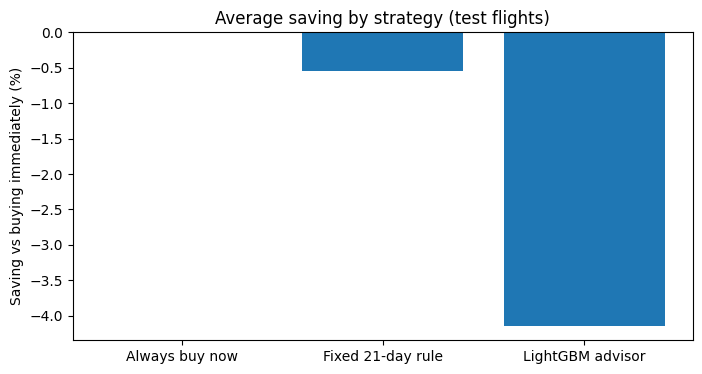

In [56]:
import matplotlib.pyplot as plt

plot_df = results[results["Strategy"] != "Perfect hindsight (upper bound)"]
plt.figure(figsize=(8, 4))
plt.bar(plot_df["Strategy"], plot_df["Saving vs buy now (%)"])
plt.ylabel("Saving vs buying immediately (%)")
plt.title("Average saving by strategy (test flights)")
plt.savefig("strategy_savings.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
def run_pipeline(threshold):
    tr = make_daily(train, threshold)
    te = make_daily(test, threshold)
    for c in cat_cols:
        cats = pd.CategoricalDtype(sorted(df[c].unique()))
        tr[c] = tr[c].astype(cats)
        te[c] = te[c].astype(cats)
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           class_weight="balanced", random_state=42, verbose=-1)
    m.fit(tr[features], tr["label"])
    te["model_wait"] = m.predict(te[features]).astype(int)
    s = simulate(te, "model_wait")
    return (1 - s["price_paid"].sum() / s["price_now"].sum()) * 100

for t in [0.03, 0.05, 0.10]:
    print(f"threshold {t:.0%}: advisor saving = {run_pipeline(t):.2f}%")

threshold 3%: advisor saving = -2.50%
threshold 5%: advisor saving = -4.14%
threshold 10%: advisor saving = -2.43%


In [58]:
import joblib

# 1. Price curves for every group, using ALL flights
app_data = make_daily(df)
app_data[group + ["days_left", "price_med", "duration", "n"]].to_csv("app_data.csv", index=False)

# 2. The trained model (from Step 6)
joblib.dump(model, "advisor_model.pkl")

# 3. Your library version, to put in requirements.txt
import lightgbm
print(lightgbm.__version__)

4.6.0
